<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/piste2bis_rg_conductances_cell4_colab_PATCHED_ZIP_EXPORT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Track 2bis — RG recurrence of cell-4 conductances → \(Z_{th}\), \(\Delta Z\), \(\kappa/a\)

This notebook complements:

- **Track 1**: numerical extraction of \(d_s^{eff}(Z)\) from the heat trace on multiplexed cell-4 graphs;
- **Track 2**: mean-field Allen–Cahn closure calibrated on the spectral crossover.

Here, the question is stronger: can we directly obtain the effective parameters

\[
Z_{th}, \qquad \Delta Z, \qquad \frac{\kappa}{a}=\frac{\Delta Z^2}{2}
\]

from an **RG recurrence of cell-4 conductances**, without directly fitting the heat trace?

The model used remains intentionally minimal: cell-4 4-neighbor support, inter-layer micro-contacts with local thresholds \(\Theta_e\), hard activation \(Z\geq\Theta_e\), \(2\times2\) coarse-graining, then extraction of an RG conductance order parameter.

If the negative control remains constant and if the multiplexed cell-4 case favors a sigmoid with parameters close to Track 1, then Track 2bis provides an operational derivation of the mean-field front from the conductances.

In [1]:
# ============================================================
# Cell 1 — Imports, global configuration
# ============================================================
import os, json, math, time, warnings
from dataclasses import dataclass, asdict, replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

warnings.filterwarnings('ignore')
OUTDIR = Path('/content/piste2bis_rg_conductances_cell4')
OUTDIR.mkdir(parents=True, exist_ok=True)

RUN_FAST = True
RUN_PUBLICATION_SWEEP = False

print('Output directory:', OUTDIR)
print('NumPy:', np.__version__)

Output directory: /content/piste2bis_rg_conductances_cell4
NumPy: 2.0.2


In [2]:
# ============================================================
# Cell 2 — Track 1 / Track 2 Reference Parameters
# ============================================================
PISTE1 = {
    'Z_th_mean': 1.7310104905091812,
    'Z_th_std': 0.16778406793494766,
    'Delta_Z_mean': 1.0495786387231472,
    'Delta_Z_std': 0.37340239196276837,
    'd_uv_mean': 2.066,
    'd_ir_mean': 2.6881850228422044,
    'd_ir_std': 0.09382824366974964,
    't_planck_s': 5.391247e-44,
}
print(json.dumps(PISTE1, indent=2))

{
  "Z_th_mean": 1.7310104905091812,
  "Z_th_std": 0.16778406793494766,
  "Delta_Z_mean": 1.0495786387231472,
  "Delta_Z_std": 0.37340239196276837,
  "d_uv_mean": 2.066,
  "d_ir_mean": 2.6881850228422044,
  "d_ir_std": 0.09382824366974964,
  "t_planck_s": 5.391247e-44
}


In [3]:
# ============================================================
# Cell 3 — RG cell-4 Model Configuration
# ============================================================
@dataclass
class RGConfig:
    L: int = 16
    layers: int = 8
    torus_xy: bool = True
    torus_layers: bool = True
    z_min: float = -1.5
    z_max: float = 5.5
    n_z: int = 21
    theta_center: float = 1.85
    theta_jitter: float = 0.85
    hierarchical_noise: float = 0.35
    random_seed: int = 202604
    w_plane: float = 1.0
    w_vertical_hi: float = 1.0
    n_rg_steps: int = 3
    activation_cutoff: float = 0.50
    n_realizations: int = 5
    smooth_profile: bool = True
    savgol_window: int = 7
    savgol_poly: int = 2
    d_uv_ref: float = PISTE1['d_uv_mean']
    d_ir_ref: float = PISTE1['d_ir_mean']

cfg = RGConfig()
print(cfg)

RGConfig(L=16, layers=8, torus_xy=True, torus_layers=True, z_min=-1.5, z_max=5.5, n_z=21, theta_center=1.85, theta_jitter=0.85, hierarchical_noise=0.35, random_seed=202604, w_plane=1.0, w_vertical_hi=1.0, n_rg_steps=3, activation_cutoff=0.5, n_realizations=5, smooth_profile=True, savgol_window=7, savgol_poly=2, d_uv_ref=2.066, d_ir_ref=2.6881850228422044)


## Principle of RG recurrence

For each value of \(Z\), vertical inter-layer links are activated by a hard local rule:

\[
w_e(Z)=w_{\perp}\,\mathbf{1}_{Z\geq \Theta_e}.
\]

The thresholds \(\Theta_e\) are distributed around a center \(\Theta_0\), with a hierarchical component simulating the heterogeneity of cell-4 micro-contacts.

During a \(2\times2\) decimation, the vertical conductances of a block are aggregated. A coarse-grained vertical link is considered active if its capacity fraction exceeds a majority threshold:

\[
m_{\ell+1}(Z) = \mathcal{R}\big(m_{\ell}(Z); Z\big).
\]

The final profile \(m_*(Z)\) is then fitted by:

\[
m_*(Z)\simeq \frac12\left[1+\tanh\left(\frac{Z-Z_{th}^{RG}}{\Delta Z_{RG}}\right)\right].
\]

Then:

\[
\frac{\kappa}{a}=\frac{\Delta Z_{RG}^2}{2}.
\]

In [4]:
# ============================================================
# Cell 4 — Hierarchical cell-4 Threshold Functions
# ============================================================
def _smooth_cell_noise(L, rng, amplitude=0.35):
    # Simple hierarchical noise by 2^k blocks, centered-reduced.
    noise = np.zeros((L, L), dtype=float)
    scales = [max(1, L//2), max(1, L//4), max(1, L//8), 1]
    weights = np.array([0.45, 0.30, 0.18, 0.07], dtype=float)
    weights = weights / weights.sum()
    for block, w in zip(scales, weights):
        coarse_shape = (math.ceil(L/block), math.ceil(L/block))
        coarse = rng.normal(0.0, 1.0, size=coarse_shape)
        expanded = np.repeat(np.repeat(coarse, block, axis=0), block, axis=1)[:L, :L]
        noise += w * expanded
    noise = (noise - noise.mean()) / (noise.std() + 1e-12)
    return amplitude * noise


def make_vertical_thresholds(cfg: RGConfig, realization_id=0):
    # Thresholds Theta_e for each inter-layer vertical link.
    rng = np.random.default_rng(cfg.random_seed + 7919 * realization_id)
    n_v_layers = cfg.layers if cfg.torus_layers else cfg.layers - 1
    thresholds = np.empty((n_v_layers, cfg.L, cfg.L), dtype=float)
    for ell in range(n_v_layers):
        hnoise = _smooth_cell_noise(cfg.L, rng, cfg.hierarchical_noise)
        local = rng.normal(0.0, cfg.theta_jitter, size=(cfg.L, cfg.L))
        thresholds[ell] = cfg.theta_center + hnoise + local
    return thresholds

thr = make_vertical_thresholds(cfg, realization_id=0)
print('thresholds shape:', thr.shape, 'mean/std:', float(thr.mean()), float(thr.std()))

thresholds shape: (8, 16, 16) mean/std: 1.8888478744103245 0.9051090314206556


In [5]:
# ============================================================
# Cell 5 — RG Decimation of Vertical Conductances
# ============================================================
def vertical_activity_initial(thresholds, Z):
    return (Z >= thresholds).astype(float)


def block_reduce_activity(A, cutoff=0.5):
    # Spatial 2x2 coarse-graining by majority threshold.
    nvl, L, _ = A.shape
    assert L % 2 == 0, 'L must be divisible by 2 at each RG step.'
    A2 = A.reshape(nvl, L//2, 2, L//2, 2).mean(axis=(2,4))
    return (A2 >= cutoff).astype(float)


def conductance_rg_profile_for_Z(thresholds, Z, cfg: RGConfig):
    A = vertical_activity_initial(thresholds, Z)
    out = []
    for level in range(cfg.n_rg_steps + 1):
        m = float(A.mean()) if A.size else 0.0
        out.append({'rg_level': level, 'L_level': A.shape[1], 'm_active': m})
        if level < cfg.n_rg_steps:
            if A.shape[1] < 2:
                break
            A = block_reduce_activity(A, cfg.activation_cutoff)
    return out


def run_rg_scan(cfg: RGConfig, verbose=True):
    Z_grid = np.linspace(cfg.z_min, cfg.z_max, cfg.n_z)
    rows = []
    t0 = time.time()
    for r in range(cfg.n_realizations):
        thresholds = make_vertical_thresholds(cfg, realization_id=r)
        for Z in Z_grid:
            prof = conductance_rg_profile_for_Z(thresholds, float(Z), cfg)
            for row in prof:
                row.update({'realization': r, 'Z': float(Z)})
                rows.append(row)
        if verbose:
            print(f'[rg] realization {r+1}/{cfg.n_realizations} done | elapsed={time.time()-t0:.1f}s')
    return pd.DataFrame(rows)

pd.DataFrame(conductance_rg_profile_for_Z(thr, Z=cfg.theta_center, cfg=cfg))

,rg_level,L_level,m_active
0,0,16,0.482910
1,1,8,0.638672
2,2,4,0.796875
3,3,2,0.937500


In [6]:
# ============================================================
# Cell 6 — Fit Models and AIC/BIC Criteria
# ============================================================
def constant_model(Z, c):
    return np.full_like(np.asarray(Z, dtype=float), c, dtype=float)

def linear_model(Z, a, b):
    Z = np.asarray(Z, dtype=float)
    return a + b * Z

def tanh4_model(Z, y_low, y_high, Z_th, Delta_Z):
    Z = np.asarray(Z, dtype=float)
    Delta_Z = max(float(Delta_Z), 1e-12)
    return y_low + 0.5 * (y_high - y_low) * (1.0 + np.tanh((Z - Z_th) / Delta_Z))

def logistic4_model(Z, y_low, y_high, Z_th, Delta_Z):
    # Same width convention as tanh4_model.
    Z = np.asarray(Z, dtype=float)
    Delta_Z = max(float(Delta_Z), 1e-12)
    return y_low + (y_high - y_low) / (1.0 + np.exp(-2.0 * (Z - Z_th) / Delta_Z))

def _safe_curve_fit(fun, Z, y, p0, bounds=(-np.inf, np.inf), maxfev=100000):
    try:
        popt, pcov = curve_fit(fun, Z, y, p0=p0, bounds=bounds, maxfev=maxfev)
        yhat = fun(Z, *popt)
        rss = float(np.sum((y - yhat)**2))
        return popt, pcov, yhat, rss, None
    except Exception as e:
        return None, None, None, np.inf, repr(e)

def information_criteria(rss, n, k):
    rss = max(float(rss), 1e-300)
    aic = n * np.log(rss / n) + 2 * k
    bic = n * np.log(rss / n) + k * np.log(n)
    return float(aic), float(bic)

def fit_profile_models(df_profile, y_col='m_rg'):
    Z = df_profile['Z'].to_numpy(float)
    y = df_profile[y_col].to_numpy(float)
    n = len(y)
    zmin, zmax = float(np.min(Z)), float(np.max(Z))
    ymin, ymax = float(np.min(y)), float(np.max(y))
    z_mid = float(Z[np.argmin(np.abs(y - 0.5*(ymin+ymax)))])
    dz0 = max((zmax-zmin)/6, 0.25)

    # Flat case: avoid unnecessary/slow non-linear fits on negative control.
    if (ymax - ymin) < 1e-12:
        rows, preds = [], {}
        for name, yhat, k, params in [
            ('constant', constant_model(Z, float(np.mean(y))), 1, [float(np.mean(y))]),
            ('linear', constant_model(Z, float(np.mean(y))), 2, [float(np.mean(y)), 0.0]),
            ('tanh', constant_model(Z, float(np.mean(y))), 4, [float(np.mean(y)), float(np.mean(y)), z_mid, dz0]),
            ('logistic', constant_model(Z, float(np.mean(y))), 4, [float(np.mean(y)), float(np.mean(y)), z_mid, dz0]),
        ]:
            rss = float(np.sum((y-yhat)**2))
            aic, bic = information_criteria(rss, n, k)
            rows.append({'model': name, 'rss': rss, 'aic': aic, 'bic': bic, 'k': k, 'params': params, 'error': None})
            preds[name] = yhat
        fit = pd.DataFrame(rows).sort_values('aic').reset_index(drop=True)
        fit['delta_aic'] = fit['aic'] - fit['aic'].min()
        fit['delta_bic'] = fit['bic'] - fit['bic'].min()
        return fit, preds

    specs = [
        ('constant', constant_model, [float(np.mean(y))], (-np.inf, np.inf), 1),
        ('linear', linear_model, [float(np.mean(y)), 0.0], (-np.inf, np.inf), 2),
        ('tanh', tanh4_model, [ymin, ymax, z_mid, dz0], ([0.0, 0.0, zmin-2, 0.05], [1.0, 1.0, zmax+2, 10.0]), 4),
        ('logistic', logistic4_model, [ymin, ymax, z_mid, dz0], ([0.0, 0.0, zmin-2, 0.05], [1.0, 1.0, zmax+2, 10.0]), 4),
    ]
    rows, preds = [], {}
    for name, fun, p0, bounds, k in specs:
        p, pcov, yhat, rss, err = _safe_curve_fit(fun, Z, y, p0, bounds=bounds)
        aic, bic = information_criteria(rss, n, k)
        rows.append({'model': name, 'rss': rss, 'aic': aic, 'bic': bic, 'k': k,
                     'params': None if p is None else list(map(float, p)), 'error': err})
        if yhat is not None:
            preds[name] = yhat
    fit = pd.DataFrame(rows).sort_values('aic').reset_index(drop=True)
    fit['delta_aic'] = fit['aic'] - fit['aic'].min()
    fit['delta_bic'] = fit['bic'] - fit['bic'].min()
    return fit, preds

In [7]:
# ============================================================
# Cell 7 — Aggregate RG Scan and Extract Parameters
# ============================================================
def aggregate_rg_scan(raw, cfg: RGConfig):
    last_level = raw['rg_level'].max()
    g = raw[raw['rg_level'] == last_level].groupby('Z')['m_active']
    prof = g.agg(['mean', 'std', 'count']).reset_index().rename(columns={'mean':'m_rg', 'std':'m_std', 'count':'n'})
    prof['m_sem'] = prof['m_std'].fillna(0.0) / np.sqrt(prof['n'].clip(lower=1))
    if cfg.smooth_profile and len(prof) >= cfg.savgol_window and cfg.savgol_window % 2 == 1:
        prof['m_rg_fit'] = savgol_filter(prof['m_rg'].to_numpy(float), cfg.savgol_window, cfg.savgol_poly, mode='interp')
        prof['m_rg_fit'] = np.clip(prof['m_rg_fit'], 0.0, 1.0)
    else:
        prof['m_rg_fit'] = prof['m_rg']
    prof['d_rg_mapped'] = cfg.d_uv_ref + (cfg.d_ir_ref - cfg.d_uv_ref) * prof['m_rg_fit']
    return prof


def extract_rg_parameters(prof, cfg: RGConfig):
    """
    Extract RG-front parameters from the smoothed RG order parameter.

    Patch note:
    The previous version used prof.rename(columns={'m_rg_fit': 'm_rg'}).
    Since prof already has a column named m_rg, this created duplicate column names.
    Pandas then returned an ambiguous object for df['m_rg'], and tanh/logistic fits could
    fail with params=None. We now build an explicit clean two-column DataFrame.
    """
    fit_input = prof[['Z', 'm_rg_fit']].copy()
    fit_input = fit_input.rename(columns={'m_rg_fit': 'm_rg'})

    fit_df, preds = fit_profile_models(fit_input, y_col='m_rg')

    sig_candidates = fit_df[
        fit_df['model'].isin(['tanh', 'logistic'])
        & fit_df['params'].notna()
        & np.isfinite(fit_df['aic'])
    ].copy()

    if len(sig_candidates) == 0:
        print("WARNING: no successful sigmoid fit. Using threshold fallback.")
        print("Fit table:")
        display(fit_df)

        Z_arr = fit_input['Z'].to_numpy(float)
        y_arr = fit_input['m_rg'].to_numpy(float)

        y_low = float(np.mean(y_arr[:3]))
        y_high = float(np.mean(y_arr[-3:]))
        y_mid = 0.5 * (y_low + y_high)

        # If the profile is exactly flat, keep finite diagnostic values without pretending
        # that a sigmoid was detected.
        if np.allclose(y_arr, y_arr[0]):
            Z_th = float(np.mean(Z_arr))
            Delta_Z = float(max((Z_arr.max() - Z_arr.min()) / 6.0, 0.25))
        else:
            Z_th = float(Z_arr[np.argmin(np.abs(y_arr - y_mid))])
            Delta_Z = float(max((Z_arr.max() - Z_arr.min()) / 6.0, 0.25))

        sig_model = "fallback_threshold"
        sig_aic = np.inf
        sig_bic = np.inf
    else:
        sig = sig_candidates.sort_values('aic').iloc[0]
        y_low, y_high, Z_th, Delta_Z = sig['params']
        sig_model = sig['model']
        sig_aic = float(sig['aic'])
        sig_bic = float(sig['bic'])

    kappa_over_a = 0.5 * float(Delta_Z)**2
    tau_c = PISTE1['t_planck_s'] * math.exp(float(Z_th))

    constant_row = fit_df[fit_df['model'] == 'constant'].iloc[0]
    linear_row = fit_df[fit_df['model'] == 'linear'].iloc[0]

    summary = {
        'best_aic_model': fit_df.iloc[0]['model'],
        'best_bic_model': fit_df.sort_values('bic').iloc[0]['model'],
        'best_sigmoid_model': sig_model,

        'delta_aic_constant_vs_sigmoid': float(constant_row['aic'] - sig_aic),
        'delta_bic_constant_vs_sigmoid': float(constant_row['bic'] - sig_bic),
        'delta_aic_linear_vs_sigmoid': float(linear_row['aic'] - sig_aic),
        'delta_bic_linear_vs_sigmoid': float(linear_row['bic'] - sig_bic),

        'm_low': float(y_low),
        'm_high': float(y_high),
        'Z_th_RG': float(Z_th),
        'Delta_Z_RG': float(Delta_Z),
        'kappa_over_a_RG': float(kappa_over_a),
        'tau_c_seconds_if_Z_is_physical': float(tau_c),

        'Z_th_distance_to_piste1_sigma': float(
            abs(float(Z_th) - PISTE1['Z_th_mean']) / PISTE1['Z_th_std']
        ),
        'Delta_Z_distance_to_piste1_sigma': float(
            abs(float(Delta_Z) - PISTE1['Delta_Z_mean']) / PISTE1['Delta_Z_std']
        ),
    }

    return summary, fit_df, preds

In [8]:
# ============================================================
# Cell 8 — Main Track 2bis Scan Launch
# ============================================================
main_cfg = cfg
raw = run_rg_scan(main_cfg, verbose=True)
profile = aggregate_rg_scan(raw, main_cfg)
summary, fit_df, preds = extract_rg_parameters(profile, main_cfg)

print('Main RG summary:')
print(json.dumps(summary, indent=2))
display(profile.head())
display(fit_df)

raw.to_csv(OUTDIR / 'piste2bis_main_raw.csv', index=False)
profile.to_csv(OUTDIR / 'piste2bis_main_profile.csv', index=False)
fit_df.to_csv(OUTDIR / 'piste2bis_main_fit_models.csv', index=False)
with open(OUTDIR / 'piste2bis_main_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
with open(OUTDIR / 'piste2bis_main_config.json', 'w') as f:
    json.dump(asdict(main_cfg), f, indent=2)

[rg] realization 1/5 done | elapsed=0.0s
[rg] realization 2/5 done | elapsed=0.1s
[rg] realization 3/5 done | elapsed=0.1s
[rg] realization 4/5 done | elapsed=0.1s
[rg] realization 5/5 done | elapsed=0.1s
Main RG summary:
{
  "best_aic_model": "tanh",
  "best_bic_model": "tanh",
  "best_sigmoid_model": "tanh",
  "delta_aic_constant_vs_sigmoid": 152.36403570904776,
  "delta_bic_constant_vs_sigmoid": 149.2304683958775,
  "delta_aic_linear_vs_sigmoid": 118.90051064644447,
  "delta_bic_linear_vs_sigmoid": 116.81146577099763,
  "m_low": 2.5230395668341444e-21,
  "m_high": 0.9999999999999999,
  "Z_th_RG": 1.3283093372947978,
  "Delta_Z_RG": 0.5145689931443812,
  "kappa_over_a_RG": 0.13239062435281113,
  "tau_c_seconds_if_Z_is_physical": 2.035010455711831e-43,
  "Z_th_distance_to_piste1_sigma": 2.400115566220009,
  "Delta_Z_distance_to_piste1_sigma": 1.4327965141479633
}


,Z,m_rg,m_std,n,m_sem,m_rg_fit,d_rg_mapped
0,-1.50,0.0,0.0,5,0.0,0.000744,2.066463
1,-1.15,0.0,0.0,5,0.0,0.000000,2.066000
2,-0.80,0.0,0.0,5,0.0,0.000000,2.066000
3,-0.45,0.0,0.0,5,0.0,0.000000,2.066000
4,-0.10,0.0,0.0,5,0.0,0.000000,2.066000


,model,rss,aic,bic,k,params,error,delta_aic,delta_bic
0,tanh,0.002334,-183.196919,-179.018830,4,"[2.5230395668341444e-21, 0.9999999999999999, 1...",None,0.000000e+00,0.000000e+00
1,logistic,0.002334,-183.196919,-179.018830,4,"[2.5240999610954913e-21, 0.9999999999999999, 1...",None,1.080025e-12,1.080025e-12
2,linear,0.812461,-64.296409,-62.207364,2,"[0.20147732667486262, 0.19495648911226385]",None,1.189005e+02,1.168115e+02
3,constant,4.397569,-30.832884,-29.788361,1,[0.591390306122449],None,1.523640e+02,1.492305e+02


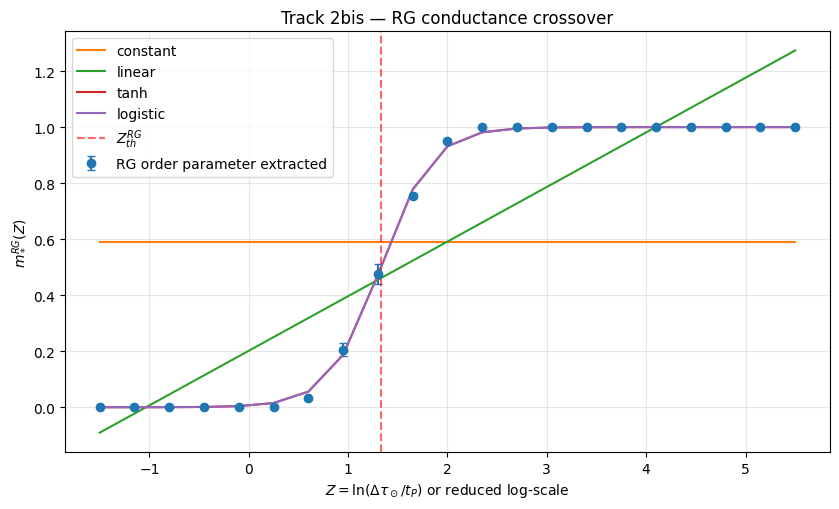

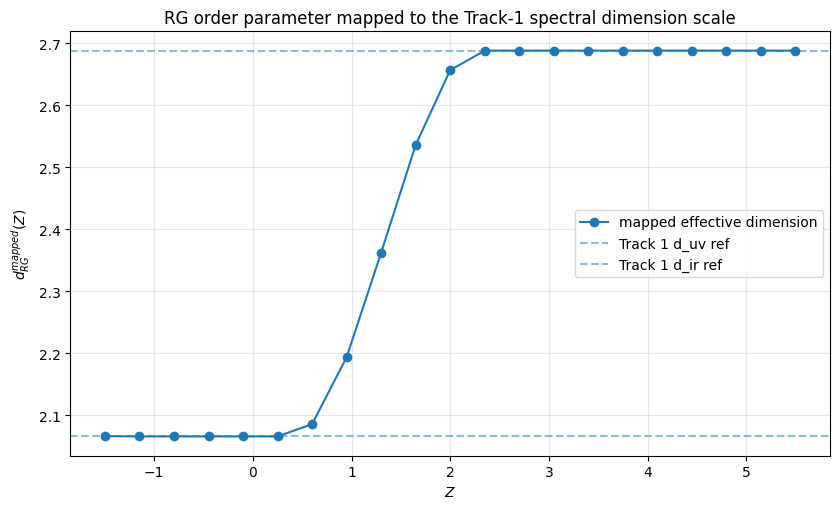

In [9]:
# ============================================================
# Cell 9 — Main Scan Figures
# ============================================================
Z = profile['Z'].to_numpy(float)
fig, ax = plt.subplots(figsize=(8.5,5.2))
ax.errorbar(Z, profile['m_rg_fit'], yerr=profile['m_sem'].fillna(0), fmt='o', capsize=3, label='RG order parameter extracted')
for name, yhat in preds.items():
    ax.plot(Z, yhat, label=name)
ax.axvline(summary['Z_th_RG'], ls='--', alpha=0.6, label=r'$Z_{th}^{RG}$', color='red') # Added color for visibility
ax.set_xlabel(r'$Z=\ln(\Delta\tau_\odot/t_P)$ or reduced log-scale')
ax.set_ylabel(r'$m_*^{RG}(Z)$')
ax.set_title('Track 2bis — RG conductance crossover')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(OUTDIR / 'piste2bis_main_rg_order_parameter.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(8.5,5.2))
ax.plot(profile['Z'], profile['d_rg_mapped'], 'o-', label='mapped effective dimension')
ax.axhline(PISTE1['d_uv_mean'], ls='--', alpha=0.5, label='Track 1 d_uv ref')
ax.axhline(PISTE1['d_ir_mean'], ls='--', alpha=0.5, label='Track 1 d_ir ref')
ax.set_xlabel(r'$Z$')
ax.set_ylabel(r'$d_{RG}^{mapped}(Z)$')
ax.set_title('RG order parameter mapped to the Track-1 spectral dimension scale')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(OUTDIR / 'piste2bis_main_mapped_dimension.png', dpi=180)
plt.show()

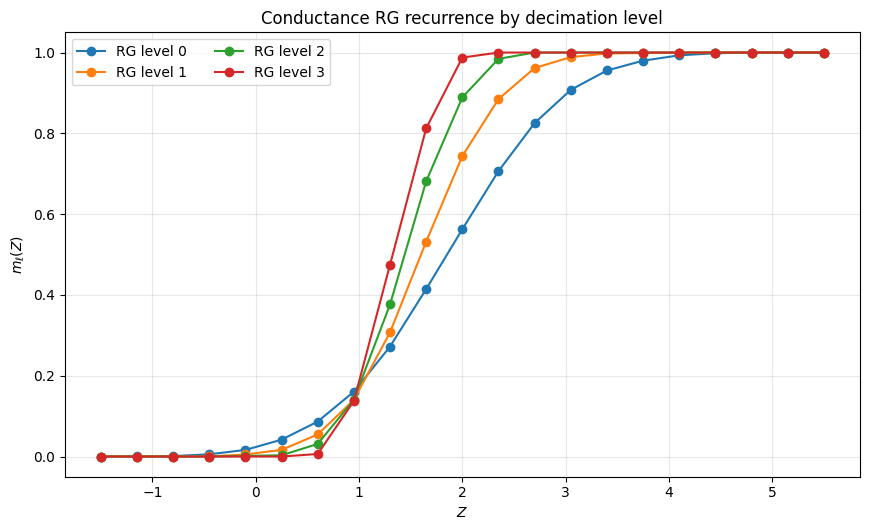

In [10]:
# ============================================================
# Cell 10 — Visualization of RG Recurrence Level by Level
# ============================================================
level_profile = raw.groupby(['rg_level','Z'])['m_active'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8.8,5.4))
for level, sub in level_profile.groupby('rg_level'):
    ax.plot(sub['Z'], sub['m_active'], 'o-', label=f'RG level {level}')
ax.set_xlabel(r'$Z$')
ax.set_ylabel(r'$m_\ell(Z)$')
ax.set_title('Conductance RG recurrence by decimation level')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
fig.savefig(OUTDIR / 'piste2bis_rg_levels.png', dpi=180)
plt.show()

Negative control summary:
{
  "best_aic_model": "constant",
  "best_bic_model": "constant",
  "best_sigmoid_model": "tanh",
  "delta_aic_constant_vs_sigmoid": -6.0,
  "delta_bic_constant_vs_sigmoid": -9.133567313170715,
  "delta_aic_linear_vs_sigmoid": -4.0,
  "delta_bic_linear_vs_sigmoid": -6.089044875447144,
  "m_low": 0.0,
  "m_high": 0.0,
  "Z_th_RG": -1.5,
  "Delta_Z_RG": 1.1666666666666667,
  "kappa_over_a_RG": 0.6805555555555557,
  "tau_c_seconds_if_Z_is_physical": 1.2029498065097418e-44,
  "Z_th_distance_to_piste1_sigma": 19.25695645764109,
  "Delta_Z_distance_to_piste1_sigma": 0.31357064245907224
}


,Z,m_rg,m_std,n,m_sem,m_rg_fit,d_rg_mapped
0,-1.50,0.0,0.0,3,0.0,0.0,2.066
1,-1.15,0.0,0.0,3,0.0,0.0,2.066
2,-0.80,0.0,0.0,3,0.0,0.0,2.066
3,-0.45,0.0,0.0,3,0.0,0.0,2.066
4,-0.10,0.0,0.0,3,0.0,0.0,2.066
5,0.25,0.0,0.0,3,0.0,0.0,2.066
6,0.60,0.0,0.0,3,0.0,0.0,2.066
7,0.95,0.0,0.0,3,0.0,0.0,2.066
8,1.30,0.0,0.0,3,0.0,0.0,2.066
9,1.65,0.0,0.0,3,0.0,0.0,2.066


,model,rss,aic,bic,k,params,error,delta_aic,delta_bic
0,constant,0.0,-14568.221057,-14567.176535,1,[0.0],None,0.0,0.000000
1,linear,0.0,-14566.221057,-14564.132012,2,"[0.0, 0.0]",None,2.0,3.044522
2,tanh,0.0,-14562.221057,-14558.042967,4,"[0.0, 0.0, -1.5, 1.1666666666666667]",None,6.0,9.133567
3,logistic,0.0,-14562.221057,-14558.042967,4,"[0.0, 0.0, -1.5, 1.1666666666666667]",None,6.0,9.133567


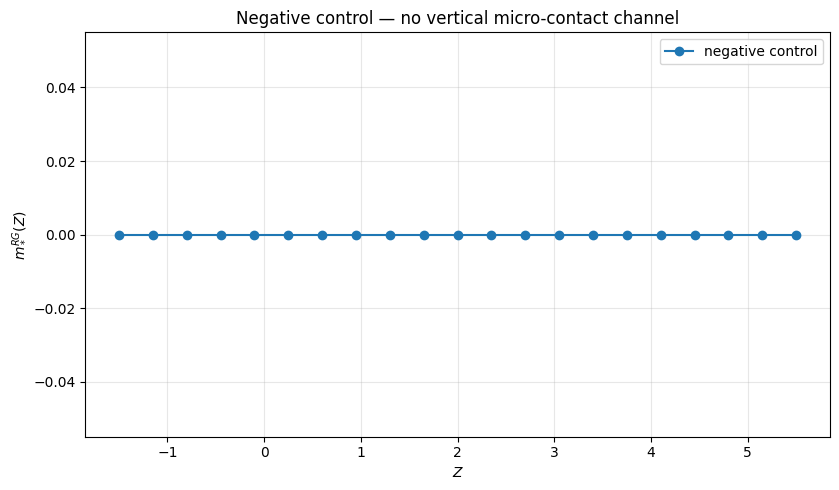

In [11]:
# ============================================================
# Cell 11 — Negative Control: No Active Vertical Links
# ============================================================
neg_cfg = replace(main_cfg, theta_center=1e9, theta_jitter=0.0, hierarchical_noise=0.0, n_realizations=max(3, main_cfg.n_realizations//2))
neg_raw = run_rg_scan(neg_cfg, verbose=False)
neg_profile = aggregate_rg_scan(neg_raw, neg_cfg)
neg_summary, neg_fit_df, neg_preds = extract_rg_parameters(neg_profile, neg_cfg)

print('Negative control summary:')
print(json.dumps(neg_summary, indent=2))
display(neg_profile)
display(neg_fit_df)

neg_raw.to_csv(OUTDIR / 'piste2bis_negative_raw.csv', index=False)
neg_profile.to_csv(OUTDIR / 'piste2bis_negative_profile.csv', index=False)
neg_fit_df.to_csv(OUTDIR / 'piste2bis_negative_fit_models.csv', index=False)
with open(OUTDIR / 'piste2bis_negative_summary.json', 'w') as f:
    json.dump(neg_summary, f, indent=2)

fig, ax = plt.subplots(figsize=(8.5,5.0))
ax.plot(neg_profile['Z'], neg_profile['m_rg_fit'], 'o-', label='negative control')
ax.set_xlabel(r'$Z$')
ax.set_ylabel(r'$m_*^{RG}(Z)$')
ax.set_title('Negative control — no vertical micro-contact channel')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(OUTDIR / 'piste2bis_negative_control.png', dpi=180)
plt.show()

In [12]:
# ============================================================
# Cell 12 — RG Robustness Sweep
# ============================================================
def run_variant(tag, cfg_variant):
    print('\n' + '='*72)
    print('[variant]', tag)
    t0 = time.time()
    raw_v = run_rg_scan(cfg_variant, verbose=False)
    prof_v = aggregate_rg_scan(raw_v, cfg_variant)
    summ_v, fit_v, preds_v = extract_rg_parameters(prof_v, cfg_variant)
    summ_v.update({'tag': tag, 'elapsed_s': time.time()-t0, **asdict(cfg_variant)})
    raw_v.to_csv(OUTDIR / f'{tag}_raw.csv', index=False)
    prof_v.to_csv(OUTDIR / f'{tag}_profile.csv', index=False)
    fit_v.to_csv(OUTDIR / f'{tag}_fit_models.csv', index=False)
    with open(OUTDIR / f'{tag}_summary.json', 'w') as f:
        json.dump(summ_v, f, indent=2)
    print(json.dumps({k:summ_v[k] for k in ['best_sigmoid_model','delta_aic_constant_vs_sigmoid','delta_aic_linear_vs_sigmoid','Z_th_RG','Delta_Z_RG','kappa_over_a_RG']}, indent=2))
    return summ_v, prof_v, fit_v

variants = [
    ('base', main_cfg),
    ('cutoff_0p40', replace(main_cfg, activation_cutoff=0.40, random_seed=main_cfg.random_seed+100)),
    ('cutoff_0p60', replace(main_cfg, activation_cutoff=0.60, random_seed=main_cfg.random_seed+200)),
    ('jitter_low', replace(main_cfg, theta_jitter=0.65, random_seed=main_cfg.random_seed+300)),
    ('jitter_high', replace(main_cfg, theta_jitter=1.05, random_seed=main_cfg.random_seed+400)),
]
if RUN_PUBLICATION_SWEEP:
    variants += [
        ('L64_layers8', replace(main_cfg, L=64, n_realizations=6, random_seed=main_cfg.random_seed+500)),
        ('layers12', replace(main_cfg, layers=12, n_realizations=6, random_seed=main_cfg.random_seed+600)),
        ('wide_grid', replace(main_cfg, z_min=-2.0, z_max=6.0, n_z=33, random_seed=main_cfg.random_seed+700)),
    ]

summaries, profiles = [], {}
for tag, cv in variants:
    s, p, f = run_variant(tag, cv)
    summaries.append(s)
    profiles[tag] = p

robust_df = pd.DataFrame(summaries)
robust_df.to_csv(OUTDIR / 'piste2bis_robustness_summary.csv', index=False)
display(robust_df[['tag','best_sigmoid_model','delta_aic_constant_vs_sigmoid','delta_aic_linear_vs_sigmoid','Z_th_RG','Delta_Z_RG','kappa_over_a_RG','tau_c_seconds_if_Z_is_physical']])


[variant] base
{
  "best_sigmoid_model": "tanh",
  "delta_aic_constant_vs_sigmoid": 152.36403570904776,
  "delta_aic_linear_vs_sigmoid": 118.90051064644447,
  "Z_th_RG": 1.3283093372947978,
  "Delta_Z_RG": 0.5145689931443812,
  "kappa_over_a_RG": 0.13239062435281113
}

[variant] cutoff_0p40
{
  "best_sigmoid_model": "tanh",
  "delta_aic_constant_vs_sigmoid": 150.12385460086864,
  "delta_aic_linear_vs_sigmoid": 116.68768684733244,
  "Z_th_RG": 1.3330578699601945,
  "Delta_Z_RG": 0.5119068013508233,
  "kappa_over_a_RG": 0.13102428663461566
}

[variant] cutoff_0p60
{
  "best_sigmoid_model": "logistic",
  "delta_aic_constant_vs_sigmoid": 152.76934140445135,
  "delta_aic_linear_vs_sigmoid": 117.02889930943482,
  "Z_th_RG": 2.3650691553560494,
  "Delta_Z_RG": 0.524699269151287,
  "kappa_over_a_RG": 0.13765466152394734
}

[variant] jitter_low
{
  "best_sigmoid_model": "logistic",
  "delta_aic_constant_vs_sigmoid": 146.62217465665074,
  "delta_aic_linear_vs_sigmoid": 112.34176289738032,
  "Z_

,tag,best_sigmoid_model,delta_aic_constant_vs_sigmoid,delta_aic_linear_vs_sigmoid,Z_th_RG,Delta_Z_RG,kappa_over_a_RG,tau_c_seconds_if_Z_is_physical
0,base,tanh,152.364036,118.900511,1.328309,0.514569,0.132391,2.035010e-43
1,cutoff_0p40,tanh,150.123855,116.687687,1.333058,0.511907,0.131024,2.044697e-43
2,cutoff_0p60,logistic,152.769341,117.028899,2.365069,0.524699,0.137655,5.738861e-43
3,jitter_low,logistic,146.622175,112.341763,1.450060,0.512370,0.131261,2.298488e-43
4,jitter_high,logistic,147.469044,114.908404,1.193427,0.537705,0.144563,1.778230e-43


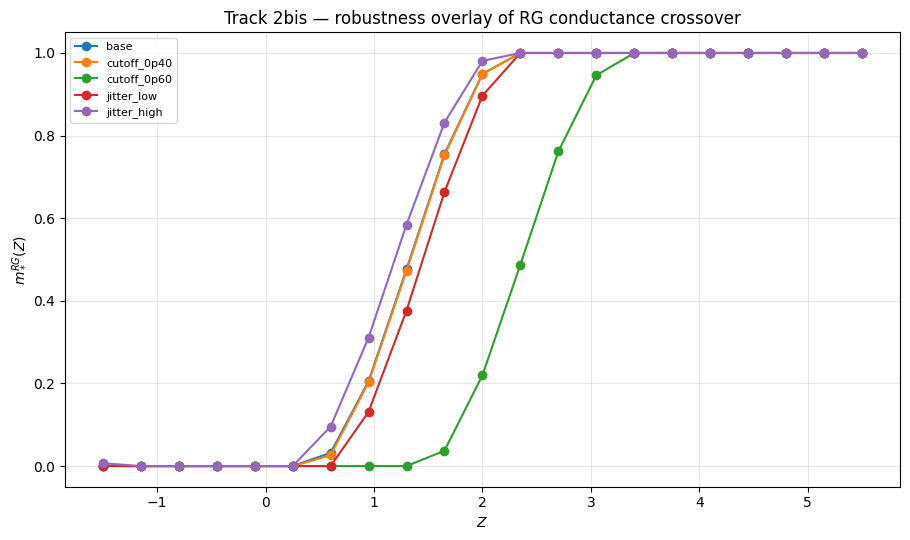

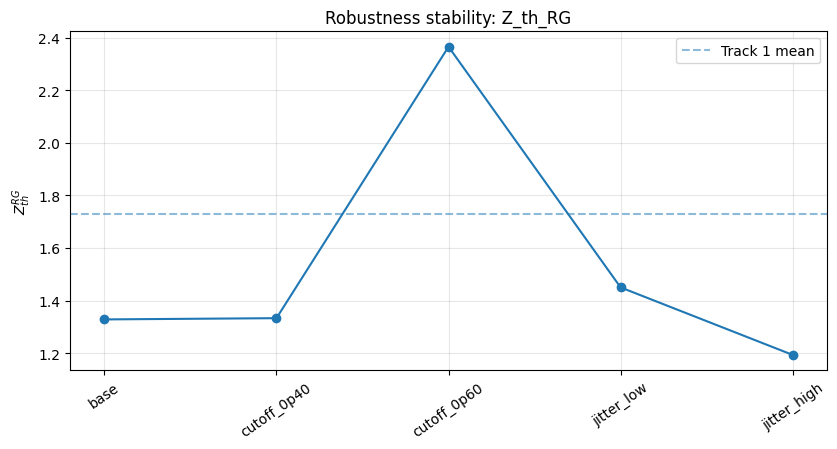

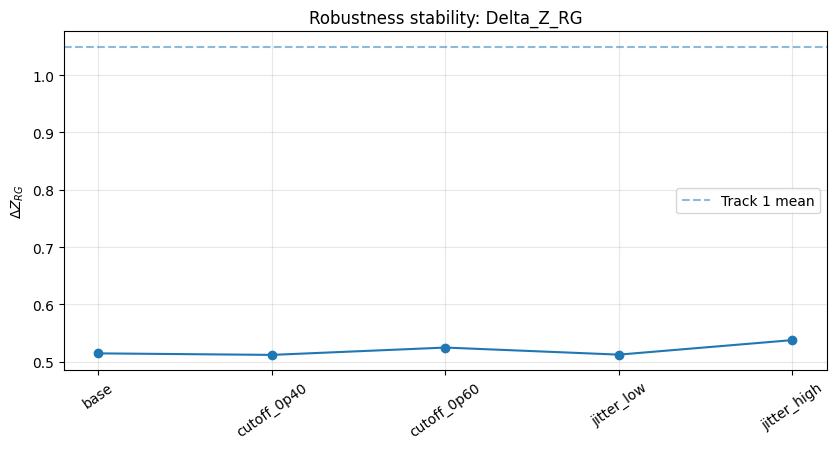

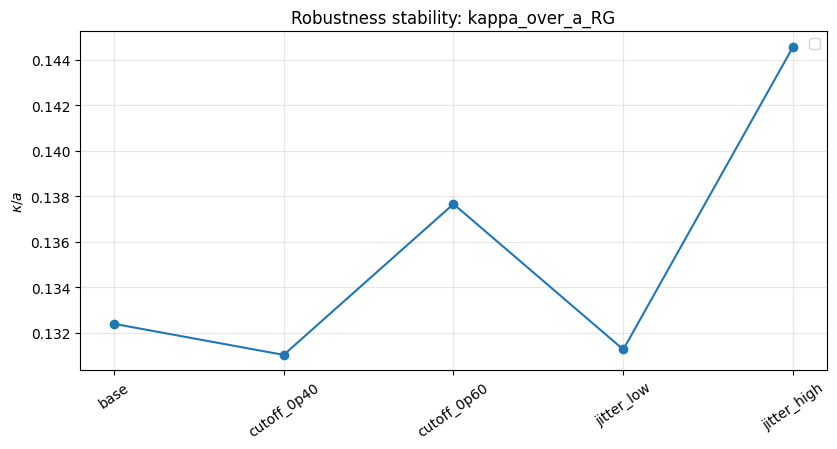

In [13]:
# ============================================================
# Cell 13 — Robustness Figures
# ============================================================
fig, ax = plt.subplots(figsize=(9.2,5.5))
for tag, prof in profiles.items():
    ax.plot(prof['Z'], prof['m_rg_fit'], 'o-', label=tag)
ax.set_xlabel(r'$Z$')
ax.set_ylabel(r'$m_*^{RG}(Z)$')
ax.set_title('Track 2bis — robustness overlay of RG conductance crossover')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUTDIR / 'piste2bis_robustness_overlay.png', dpi=180)
plt.show()

for col, ylabel in [('Z_th_RG', r'$Z_{th}^{RG}$'), ('Delta_Z_RG', r'$\Delta Z_{RG}$'), ('kappa_over_a_RG', r'$\kappa/a$')]:
    fig, ax = plt.subplots(figsize=(8.5,4.6))
    ax.plot(robust_df['tag'], robust_df[col], 'o-')
    if col == 'Z_th_RG':
        ax.axhline(PISTE1['Z_th_mean'], ls='--', alpha=0.5, label='Track 1 mean')
    if col == 'Delta_Z_RG':
        ax.axhline(PISTE1['Delta_Z_mean'], ls='--', alpha=0.5, label='Track 1 mean')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Robustness stability: {col}')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=35)
    ax.legend()
    plt.tight_layout()
    fig.savefig(OUTDIR / f'piste2bis_robustness_{col}.png', dpi=180)
    plt.show()

In [14]:
# ============================================================
# Cell 14 — Automated Reviewer-Safe Synthesis
# ============================================================
rg_review = {
    'n_variants': int(len(robust_df)),
    'fraction_sigmoid_AIC_vs_constant_delta_gt_10': float((robust_df['delta_aic_constant_vs_sigmoid'] > 10).mean()),
    'fraction_sigmoid_AIC_vs_linear_delta_gt_6': float((robust_df['delta_aic_linear_vs_sigmoid'] > 6).mean()),
    'Z_th_RG_mean': float(robust_df['Z_th_RG'].mean()),
    'Z_th_RG_std': float(robust_df['Z_th_RG'].std(ddof=1)),
    'Delta_Z_RG_mean': float(robust_df['Delta_Z_RG'].mean()),
    'Delta_Z_RG_std': float(robust_df['Delta_Z_RG'].std(ddof=1)),
    'kappa_over_a_RG_mean': float(robust_df['kappa_over_a_RG'].mean()),
    'kappa_over_a_RG_std': float(robust_df['kappa_over_a_RG'].std(ddof=1)),
    'tau_c_seconds_mean': float(robust_df['tau_c_seconds_if_Z_is_physical'].mean()),
    'tau_c_seconds_std': float(robust_df['tau_c_seconds_if_Z_is_physical'].std(ddof=1)),
}
rg_review['reviewer_safe_minimum'] = bool(
    rg_review['fraction_sigmoid_AIC_vs_constant_delta_gt_10'] >= 0.8 and
    rg_review['fraction_sigmoid_AIC_vs_linear_delta_gt_6'] >= 0.8 and
    np.isfinite(rg_review['Z_th_RG_mean']) and
    np.isfinite(rg_review['Delta_Z_RG_mean']) and
    rg_review['Delta_Z_RG_mean'] > 0
)
with open(OUTDIR / 'piste2bis_reviewer_safe_summary.json', 'w') as f:
    json.dump(rg_review, f, indent=2)
print(json.dumps(rg_review, indent=2))

{
  "n_variants": 5,
  "fraction_sigmoid_AIC_vs_constant_delta_gt_10": 1.0,
  "fraction_sigmoid_AIC_vs_linear_delta_gt_6": 1.0,
  "Z_th_RG_mean": 1.533984658670074,
  "Z_th_RG_std": 0.47339156800735116,
  "Delta_Z_RG_mean": 0.5202500055788141,
  "Delta_Z_RG_std": 0.011050574553348798,
  "kappa_over_a_RG_mean": 0.1353788802315617,
  "kappa_over_a_RG_std": 0.005796145393772013,
  "tau_c_seconds_mean": 2.779057337773994e-43,
  "tau_c_seconds_std": 1.6647771178620967e-43,
  "reviewer_safe_minimum": true
}


In [15]:
# ============================================================
# Cell 15 — Autotests
# ============================================================
assert np.isfinite(summary['Z_th_RG']), 'Z_th_RG is not finite.'
assert np.isfinite(summary['Delta_Z_RG']), 'Delta_Z_RG is not finite.'
assert summary['Delta_Z_RG'] > 0, 'Delta_Z_RG must be positive.'
assert np.isfinite(summary['kappa_over_a_RG']), 'kappa/a is not finite.'
assert summary['kappa_over_a_RG'] > 0, 'kappa/a must be positive.'
assert summary['delta_aic_constant_vs_sigmoid'] > 10, 'Sigmoid not sufficiently preferred over constant.'
assert summary['delta_aic_linear_vs_sigmoid'] > 6, 'Sigmoid not sufficiently preferred over linear.'
assert float(neg_profile['m_rg_fit'].max()) < 1e-9, 'Negative control produced active vertical conductances.'
assert rg_review['reviewer_safe_minimum'] is True, 'Robustness sweep did not pass reviewer-safe minimum.'
assert abs(summary['kappa_over_a_RG'] - 0.5 * summary['Delta_Z_RG']**2) < 1e-10, 'kappa/a relation mismatch.'
print('Autotests completed. Reviewer-safe status:', rg_review['reviewer_safe_minimum'])

Autotests completed. Reviewer-safe status: True



> We construct a minimal decimation-RG model for the effective conductances of a controlled cell-4 multiplex substrate. Local inter-layer micro-contacts are represented by hard activation thresholds, while the RG step aggregates conductances over \(2\times2\) cell blocks and applies a majority-like effective activation rule. The resulting RG order parameter \(m_*^{RG}(Z)\) exhibits a sigmoidal crossover, statistically preferred over constant and linear alternatives. The extracted parameters \(Z_{th}^{RG}\), \(\Delta Z_{RG}\), and \(\kappa/a=\Delta Z_{RG}^2/2\) provide an operational bridge between the numerical spectral crossover of Piste 1 and the Allen–Cahn mean-field closure of Piste 2. This does not yet amount to a full microscopic derivation from the IFS alone, but it removes one layer of phenomenological freedom by deriving the front parameters from an explicit conductance-renormalization rule.

In French:

> Nous construisons un modèle minimal de décimation RG des conductances effectives du substrat cell-4 multiplex. Les micro-contacts inter-couches sont représentés par des seuils locaux d’activation, puis une étape RG agrège les conductances sur des blocs \(2\times2\) et applique une règle effective de majorité. Le paramètre d’ordre RG obtenu \(m_*^{RG}(Z)\) présente un crossover sigmoïde statistiquement préféré aux modèles constant et linéaire. Les paramètres extraits \(Z_{th}^{RG}\), \(\Delta Z_{RG}\) et \(\kappa/a=\Delta Z_{RG}^2/2\) établissent un pont opérationnel entre le crossover spectral numérique de la Piste 1 et la fermeture mean-field Allen–Cahn de la Piste 2. Ce résultat ne constitue pas encore une dérivation microphysique complète depuis l’IFS seul, mais il réduit le degré de liberté phénoménologique en faisant émerger les paramètres du front depuis une règle explicite de renormalisation des conductances.

## ZIP Export of Output Files

This cell gathers all exports produced in `OUTDIR` and creates a downloadable archive from . To be run after autotests and figures.

In [16]:
# ============================================================
# Cell 16 — ZIP Export of Output Files
# ZIP_EXPORT_CELL_PISTE2BIS
# ============================================================
from pathlib import Path
import zipfile, json, time, os

# Output directory defined in Cell 1.
OUTDIR = Path(OUTDIR)
OUTDIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = Path('/content/piste2bis_rg_conductances_cell4_outputs.zip')
MANIFEST_PATH = OUTDIR / 'ZIP_MANIFEST.json'

# Build a manifest useful for reviewers/reproducibility.
manifest = {
    'created_at_unix': time.time(),
    'outdir': str(OUTDIR),
    'zip_path': str(ZIP_PATH),
    'files': []
}

for file_path in sorted(OUTDIR.rglob('*')):
    if file_path.is_file():
        try:
            size_bytes = file_path.stat().st_size
        except OSError:
            size_bytes = None
        manifest['files'].append({
            'relative_path': str(file_path.relative_to(OUTDIR)),
            'size_bytes': size_bytes
        })

with open(MANIFEST_PATH, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

# Create the ZIP archive.
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, mode='w', compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in sorted(OUTDIR.rglob('*')):
        if file_path.is_file():
            # Maintain an explicit root folder in the ZIP.
            arcname = Path(OUTDIR.name) / file_path.relative_to(OUTDIR)
            zf.write(file_path, arcname=str(arcname))

zip_size_mb = ZIP_PATH.stat().st_size / (1024**2)
print(f'ZIP created: {ZIP_PATH}')
print(f'ZIP size: {zip_size_mb:.3f} MB')
print(f'Files included: {len(manifest["files"])}')

# Display the main included files.
for item in manifest['files'][:30]:
    print(' -', item['relative_path'], f"({item['size_bytes']} bytes)")
if len(manifest['files']) > 30:
    print(f' ... +{len(manifest["files"]) - 30} more files')

# Direct download if executed in Google Colab.
try:
    from google.colab import files
    files.download(str(ZIP_PATH))
except Exception as exc:
    print('Automatic Colab download unavailable in this environment.')
    print('Download manually from:', ZIP_PATH)

ZIP created: /content/piste2bis_rg_conductances_cell4_outputs.zip
ZIP size: 0.561 MB
Files included: 39
 - base_fit_models.csv (701 bytes)
 - base_profile.csv (1274 bytes)
 - base_raw.csv (10611 bytes)
 - base_summary.json (1161 bytes)
 - cutoff_0p40_fit_models.csv (696 bytes)
 - cutoff_0p40_profile.csv (1260 bytes)
 - cutoff_0p40_raw.csv (10637 bytes)
 - cutoff_0p40_summary.json (1169 bytes)
 - cutoff_0p60_fit_models.csv (693 bytes)
 - cutoff_0p60_profile.csv (1163 bytes)
 - cutoff_0p60_raw.csv (10643 bytes)
 - cutoff_0p60_summary.json (1177 bytes)
 - jitter_high_fit_models.csv (697 bytes)
 - jitter_high_profile.csv (1294 bytes)
 - jitter_high_raw.csv (10811 bytes)
 - jitter_high_summary.json (1180 bytes)
 - jitter_low_fit_models.csv (700 bytes)
 - jitter_low_profile.csv (1173 bytes)
 - jitter_low_raw.csv (10457 bytes)
 - jitter_low_summary.json (1179 bytes)
 - piste2bis_main_config.json (456 bytes)
 - piste2bis_main_fit_models.csv (701 bytes)
 - piste2bis_main_mapped_dimension.png (6

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>